In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)



sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

credit_df = pd.read_csv("../data/raw/creditcard.csv")

ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("Fraud Dataset")
display(fraud_df.head())

print("Credit Card Dataset")
display(credit_df.head())

print("IP Address Dataset")
display(ip_df.head())

Fraud Dataset


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


Credit Card Dataset


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


IP Address Dataset


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [4]:
print("Fraud Dataset Shape:", fraud_df.shape)
print("Credit Dataset Shape:", credit_df.shape)
print("IP Dataset Shape:", ip_df.shape)

Fraud Dataset Shape: (151112, 11)
Credit Dataset Shape: (284807, 31)
IP Dataset Shape: (138846, 3)


In [5]:
print("Fraud Dataset Columns")
print(fraud_df.columns)

print("\nCredit Dataset Columns")
print(credit_df.columns)

print("\nIP Dataset Columns")
print(ip_df.columns)

Fraud Dataset Columns
Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='str')

Credit Dataset Columns
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

IP Dataset Columns
Index(['lower_bound_ip_address', 'upper_bound_ip_address', 'country'], dtype='str')


In [6]:
print("Fraud Dataset Info")
fraud_df.info()

print("\nCredit Dataset Info")
credit_df.info()

print("\nIP Dataset Info")
ip_df.info()

Fraud Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB

Credit Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-nul

In [7]:
print("Fraud Dataset Summary")
display(fraud_df.describe())

print("Credit Dataset Summary")
display(credit_df.describe())

print("IP Dataset Summary")
display(ip_df.describe())

Fraud Dataset Summary


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


Credit Dataset Summary


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


IP Dataset Summary


,lower_bound_ip_address,upper_bound_ip_address
count,1.388460e+05,1.388460e+05
mean,2.724532e+09,2.724557e+09
std,8.975215e+08,8.974979e+08
min,1.677722e+07,1.677747e+07
25%,1.919930e+09,1.920008e+09
50%,3.230887e+09,3.230888e+09
75%,3.350465e+09,3.350466e+09
max,3.758096e+09,3.758096e+09


In [8]:
print("Fraud Dataset Summary")
display(fraud_df.describe())

print("Credit Dataset Summary")
display(credit_df.describe())

print("IP Dataset Summary")
display(ip_df.describe())

Fraud Dataset Summary


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


Credit Dataset Summary


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


IP Dataset Summary


,lower_bound_ip_address,upper_bound_ip_address
count,1.388460e+05,1.388460e+05
mean,2.724532e+09,2.724557e+09
std,8.975215e+08,8.974979e+08
min,1.677722e+07,1.677747e+07
25%,1.919930e+09,1.920008e+09
50%,3.230887e+09,3.230888e+09
75%,3.350465e+09,3.350466e+09
max,3.758096e+09,3.758096e+09


In [11]:
print("Missing Values in Fraud Dataset")
display(fraud_df.isnull().sum())

print("Missing Values in Credit Dataset")
display(credit_df.isnull().sum())

print("Missing Values in IP Dataset")
display(ip_df.isnull().sum())

Missing Values in Fraud Dataset


user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Missing Values in Credit Dataset


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Missing Values in IP Dataset


lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64

In [10]:
print("Duplicate Rows in Fraud Dataset:", fraud_df.duplicated().sum())

print("Duplicate Rows in Credit Dataset:", credit_df.duplicated().sum())

print("Duplicate Rows in IP Dataset:", ip_df.duplicated().sum())

Duplicate Rows in Fraud Dataset: 0
Duplicate Rows in Credit Dataset: 1081
Duplicate Rows in IP Dataset: 0


In [12]:
fraud_clean = fraud_df.copy()
credit_clean = credit_df.copy()
ip_clean = ip_df.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [13]:
print("="*60)
print("Removing Duplicate Records")
print("="*60)

print(f"Credit Card Dataset Before : {credit_clean.shape}")

duplicates = credit_clean.duplicated().sum()
print(f"Duplicate Rows Found       : {duplicates}")

credit_clean.drop_duplicates(inplace=True)

print(f"Credit Card Dataset After  : {credit_clean.shape}")

print(f"Remaining Duplicates       : {credit_clean.duplicated().sum()}")

Removing Duplicate Records
Credit Card Dataset Before : (284807, 31)
Duplicate Rows Found       : 1081
Credit Card Dataset After  : (283726, 31)
Remaining Duplicates       : 0


In [14]:
fraud_clean["signup_time"] = pd.to_datetime(
    fraud_clean["signup_time"]
)

fraud_clean["purchase_time"] = pd.to_datetime(
    fraud_clean["purchase_time"]
)

print("Date columns converted successfully.\n")

print(fraud_clean.dtypes)

Date columns converted successfully.

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object


In [15]:
fraud_clean["ip_address"] = fraud_clean["ip_address"].astype("int64")

print("IP Address datatype:")
print(fraud_clean["ip_address"].dtype)

IP Address datatype:
int64


In [16]:


print("="*60)
print("Fraud Dataset")
print("="*60)

display(fraud_clean.head())

print(fraud_clean.info())

print("="*60)
print("Credit Dataset")
print("="*60)

display(credit_clean.head())

print(credit_clean.info())

print("="*60)
print("IP Dataset")
print("="*60)

display(ip_clean.head())

print(ip_clean.info())

Fraud Dataset


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117,0


<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  int64         
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), int64(5), str(4)
memory usage: 12.7 MB
None
Credit Dataset


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB
None


In [17]:


fraud_clean.to_csv(
    "../data/processed/fraud_clean.csv",
    index=False
)

credit_clean.to_csv(
    "../data/processed/creditcard_clean.csv",
    index=False
)

ip_clean.to_csv(
    "../data/processed/ip_country_clean.csv",
    index=False
)

print("="*60)
print("Cleaned datasets saved successfully.")
print("="*60)

Cleaned datasets saved successfully.


In [18]:
import os

print(os.listdir("../data/processed"))

['creditcard_clean.csv', 'fraud_clean.csv', 'ip_country_clean.csv']


In [19]:
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

sns.set_palette("Set2")

In [20]:
print("="*60)
print("Fraud Dataset")
print("="*60)

print(f"Rows    : {fraud_clean.shape[0]}")
print(f"Columns : {fraud_clean.shape[1]}")

display(fraud_clean.head())

Fraud Dataset
Rows    : 151112
Columns : 11


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117,0


In [21]:
print("="*60)
print("Credit Card Dataset")
print("="*60)

print(f"Rows    : {credit_clean.shape[0]}")
print(f"Columns : {credit_clean.shape[1]}")

display(credit_clean.head())

Credit Card Dataset
Rows    : 283726
Columns : 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


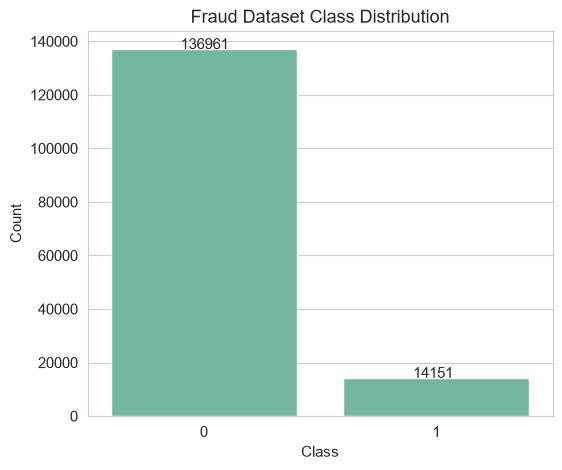

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

In [22]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="class",
    data=fraud_clean
)

plt.title("Fraud Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+0.3,p.get_height()+100)
    )

plt.show()

fraud_clean["class"].value_counts(normalize=True)*100

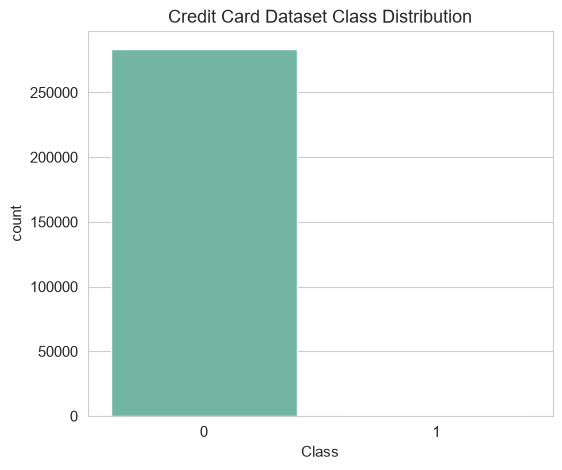

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [23]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="Class",
    data=credit_clean
)

plt.title("Credit Card Dataset Class Distribution")

plt.show()

credit_clean["Class"].value_counts(normalize=True)*100

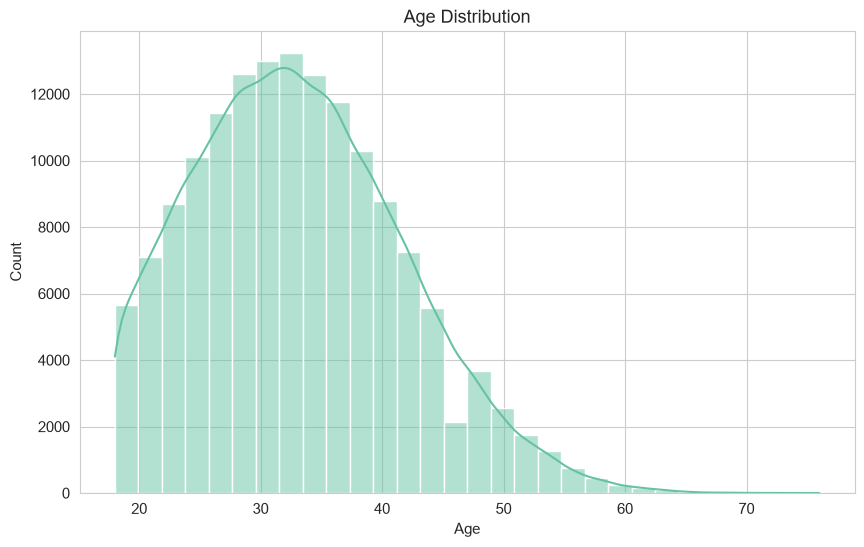

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    fraud_clean["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

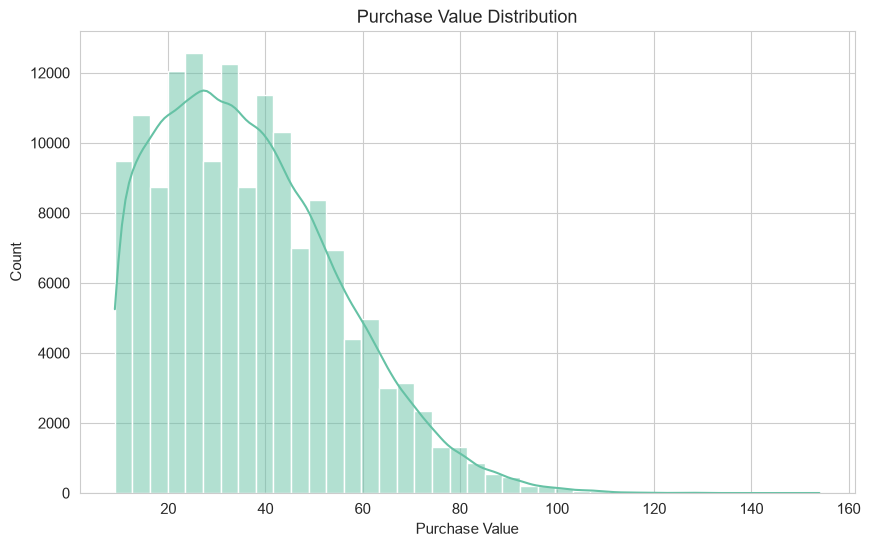

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    fraud_clean["purchase_value"],
    bins=40,
    kde=True
)

plt.title("Purchase Value Distribution")

plt.xlabel("Purchase Value")

plt.show()

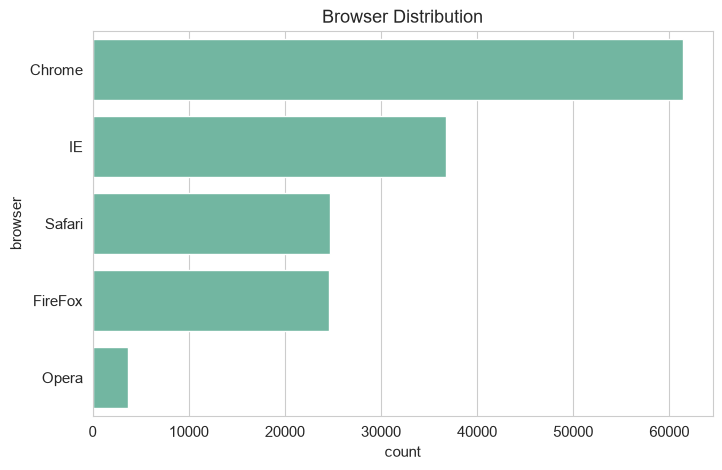

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="browser",
    data=fraud_clean,
    order=fraud_clean.browser.value_counts().index
)

plt.title("Browser Distribution")

plt.show()

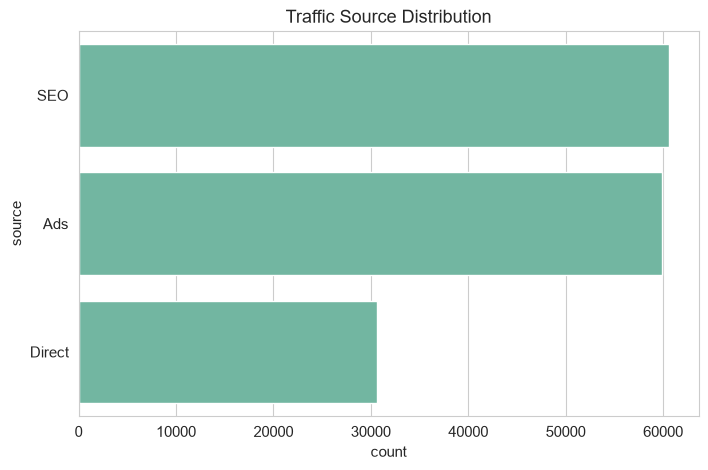

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="source",
    data=fraud_clean,
    order=fraud_clean.source.value_counts().index
)

plt.title("Traffic Source Distribution")

plt.show()

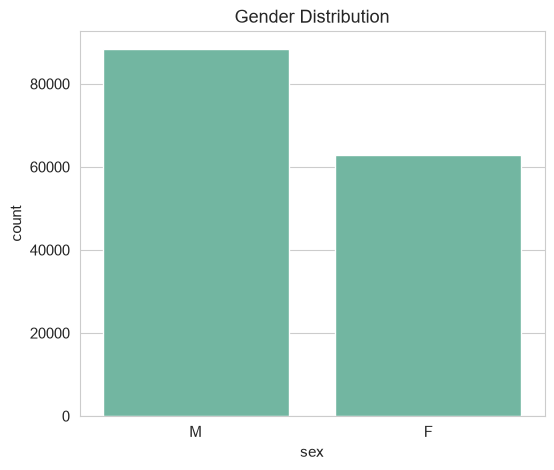

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="sex",
    data=fraud_clean
)

plt.title("Gender Distribution")

plt.show()

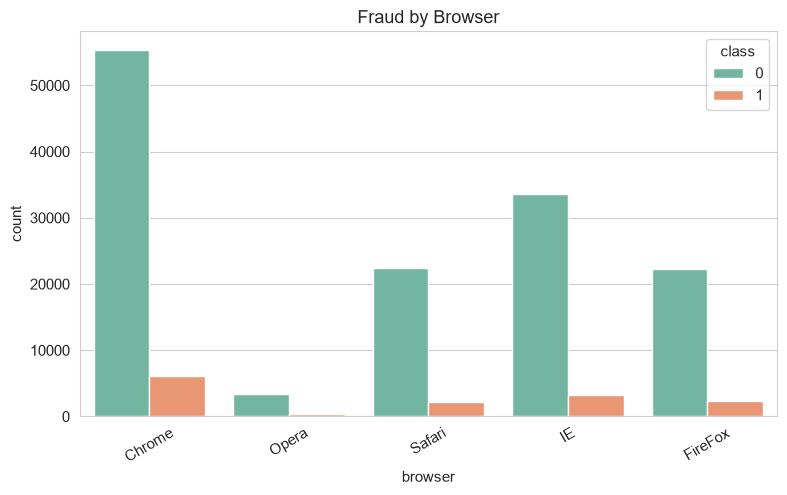

In [29]:
plt.figure(figsize=(9,5))

sns.countplot(
    x="browser",
    hue="class",
    data=fraud_clean
)

plt.title("Fraud by Browser")

plt.xticks(rotation=30)

plt.show()

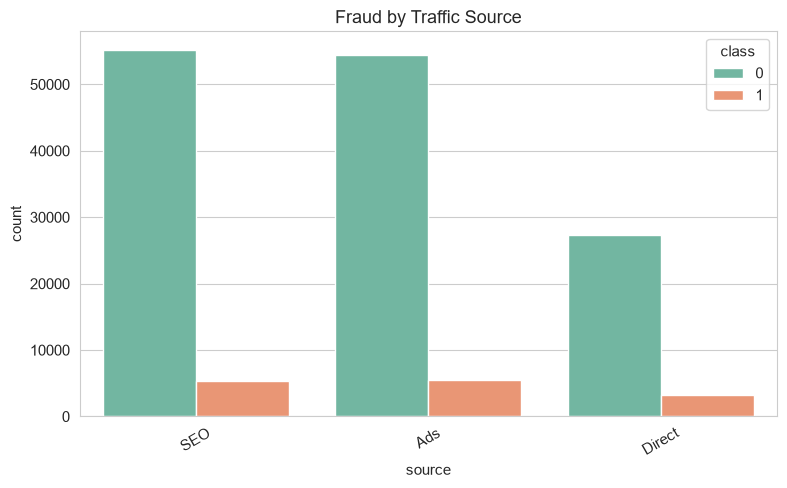

In [30]:
plt.figure(figsize=(9,5))

sns.countplot(
    x="source",
    hue="class",
    data=fraud_clean
)

plt.title("Fraud by Traffic Source")

plt.xticks(rotation=30)

plt.show()

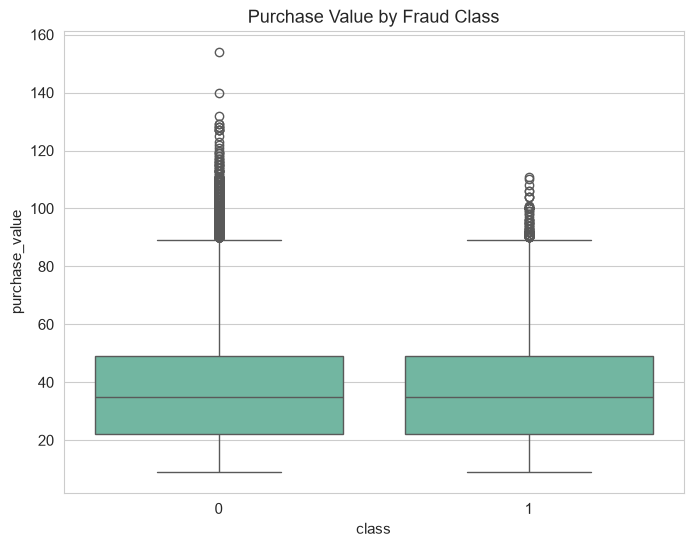

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud_clean
)

plt.title("Purchase Value by Fraud Class")

plt.show()

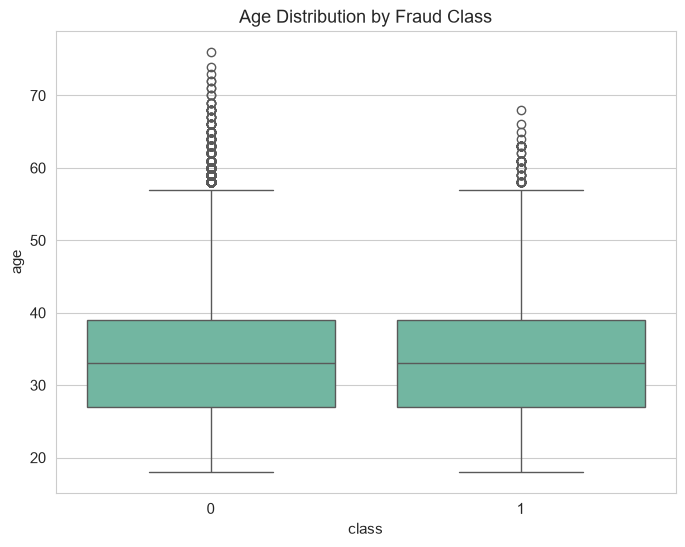

In [32]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="class",
    y="age",
    data=fraud_clean
)

plt.title("Age Distribution by Fraud Class")

plt.show()

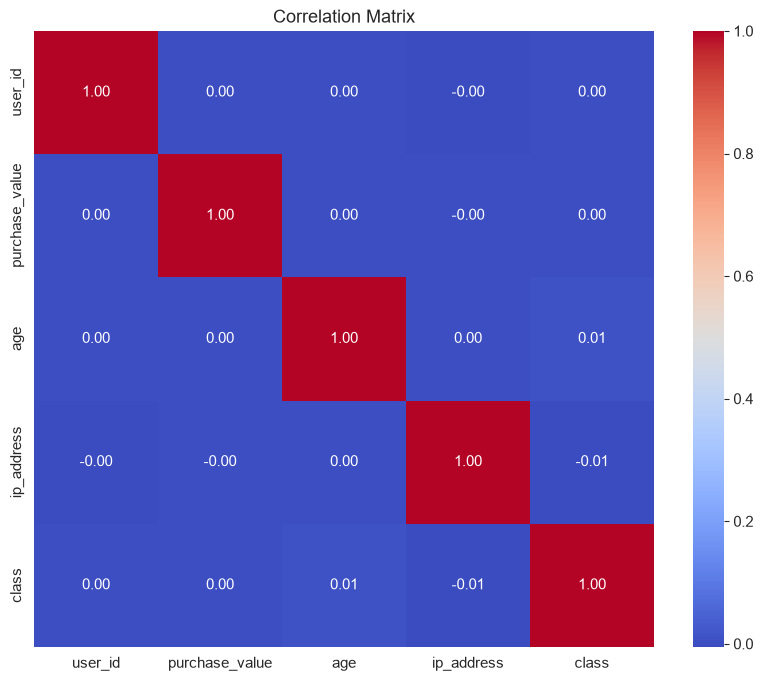

In [33]:
plt.figure(figsize=(10,8))

corr = fraud_clean.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

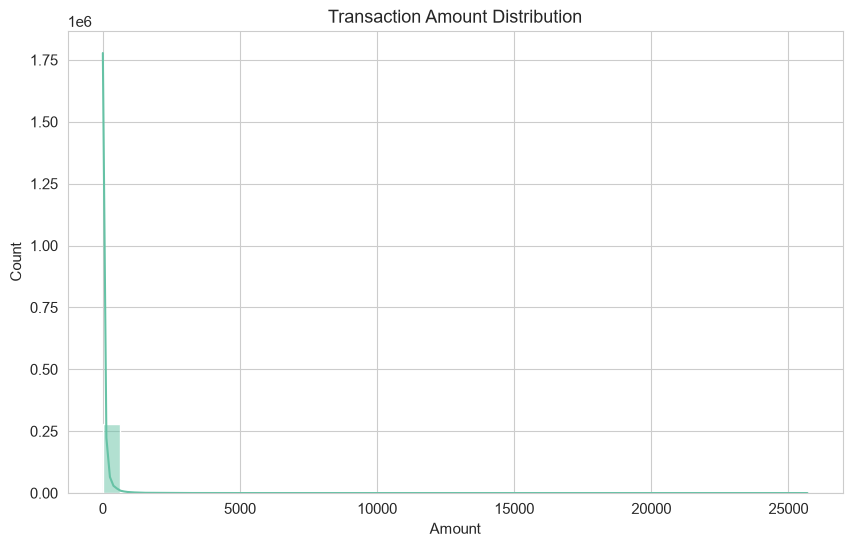

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    credit_clean["Amount"],
    bins=40,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

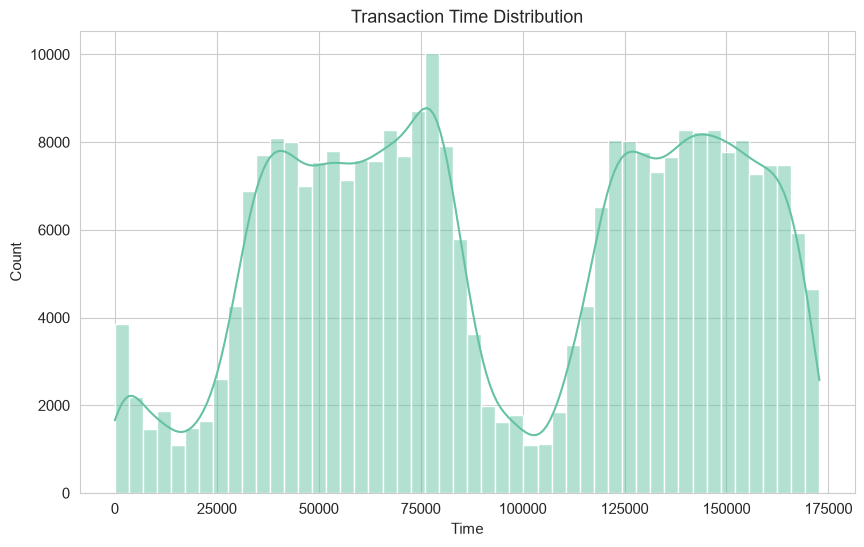

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    credit_clean["Time"],
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.show()

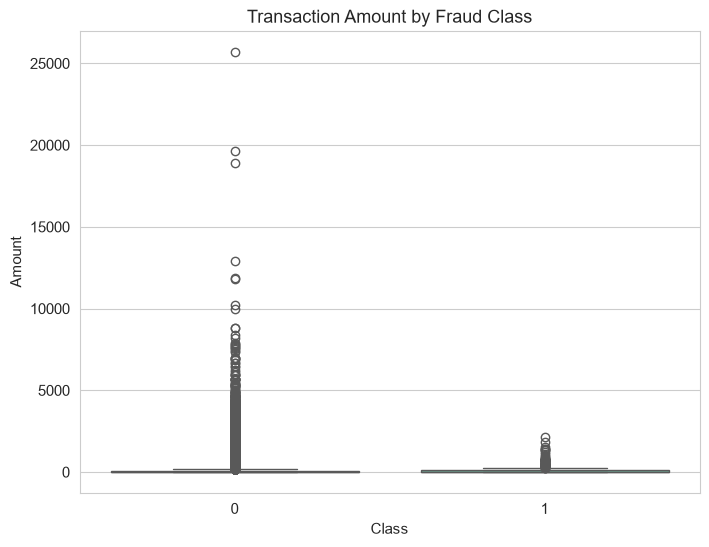

In [36]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=credit_clean
)

plt.title("Transaction Amount by Fraud Class")

plt.show()

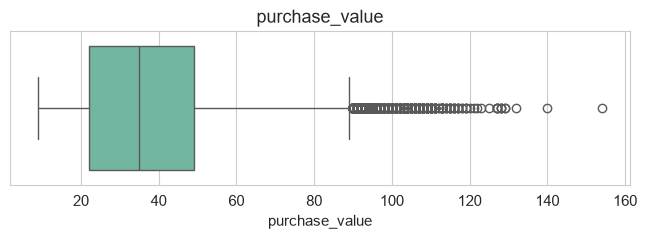

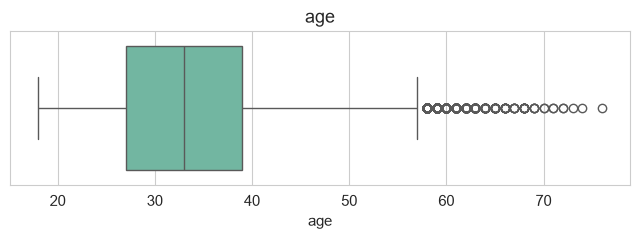

In [37]:
numeric_columns = [
    "purchase_value",
    "age"
]

for col in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=fraud_clean[col]
    )

    plt.title(col)

    plt.show()

In [38]:
print("="*60)
print("Fraud Dataset")
print("="*60)

fraud_counts = fraud_clean["class"].value_counts()

fraud_percent = fraud_clean["class"].value_counts(normalize=True)*100

fraud_summary = pd.DataFrame({

    "Count": fraud_counts,

    "Percentage": fraud_percent

})

display(fraud_summary)

print()

print("="*60)
print("Credit Card Dataset")
print("="*60)

credit_counts = credit_clean["Class"].value_counts()

credit_percent = credit_clean["Class"].value_counts(normalize=True)*100

credit_summary = pd.DataFrame({

    "Count": credit_counts,

    "Percentage": credit_percent

})

display(credit_summary)

Fraud Dataset


,Count,Percentage
class,,
0,136961,90.635423
1,14151,9.364577



Credit Card Dataset


,Count,Percentage
Class,,
0,283253,99.83329
1,473,0.16671


In [39]:
# =====================================================
# Sort IP Address Dataset
# =====================================================

ip_clean = ip_clean.sort_values(
    by="lower_bound_ip_address"
).reset_index(drop=True)

display(ip_clean.head())

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [40]:


ip_clean["lower_bound_ip_address"] = (
    ip_clean["lower_bound_ip_address"]
    .astype("int64")
)

ip_clean["upper_bound_ip_address"] = (
    ip_clean["upper_bound_ip_address"]
    .astype("int64")
)

fraud_clean["ip_address"] = fraud_clean["ip_address"].astype("int64")

print(ip_clean.dtypes)

lower_bound_ip_address    int64
upper_bound_ip_address    int64
country                     str
dtype: object


In [41]:
fraud_geo = pd.merge_asof(
    fraud_clean.sort_values("ip_address"),
    ip_clean,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

fraud_geo = fraud_geo[
    fraud_geo["ip_address"] <= fraud_geo["upper_bound_ip_address"]
]

print("Merged Dataset Shape:")
print(fraud_geo.shape)

display(fraud_geo.head())

Merged Dataset Shape:
(129146, 14)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand


In [42]:
print("Missing Countries:")

print(fraud_geo["country"].isnull().sum())

Missing Countries:
0


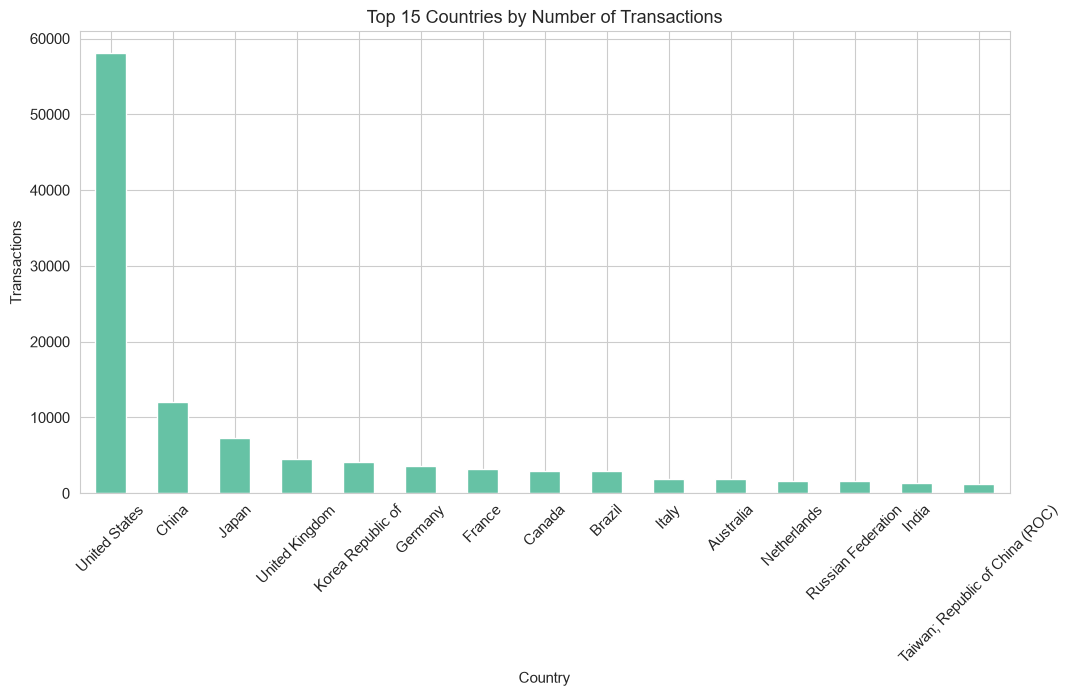

In [43]:
plt.figure(figsize=(12,6))

fraud_geo["country"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Countries by Number of Transactions")

plt.xlabel("Country")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

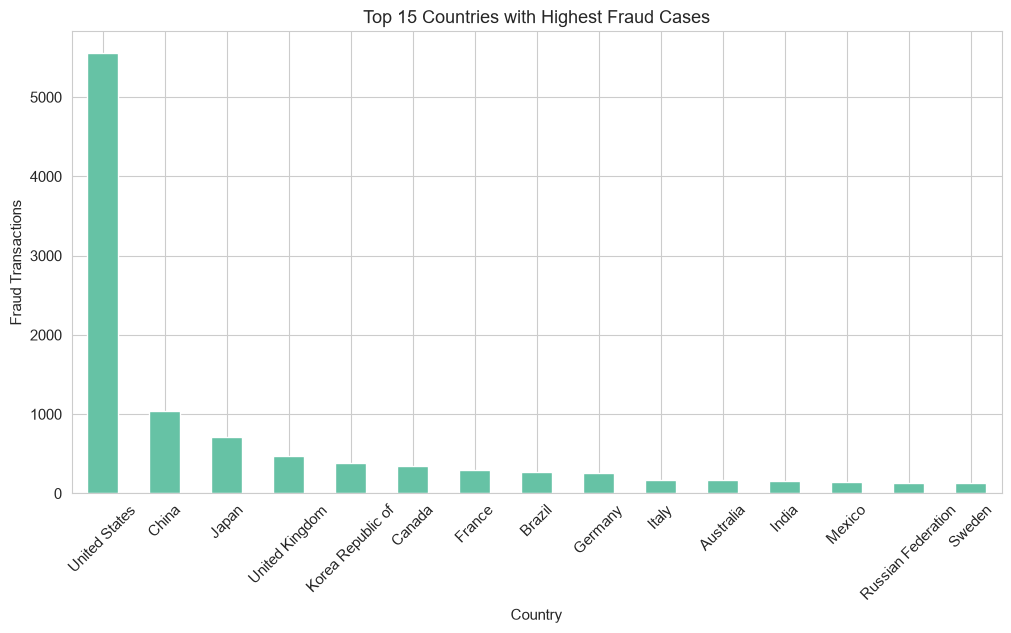

country
United States         5551
China                 1043
Japan                  715
United Kingdom         477
Korea Republic of      380
Canada                 348
France                 300
Brazil                 270
Germany                262
Italy                  166
Australia              165
India                  151
Mexico                 144
Russian Federation     134
Sweden                 131
Name: class, dtype: int64

In [44]:
country_fraud = (
    fraud_geo
    .groupby("country")["class"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

country_fraud.plot(kind="bar")

plt.title("Top 15 Countries with Highest Fraud Cases")

plt.xlabel("Country")

plt.ylabel("Fraud Transactions")

plt.xticks(rotation=45)

plt.show()

display(country_fraud)

In [45]:
country_summary = (
    fraud_geo
    .groupby("country")
    .agg(
        total_transactions=("class","count"),
        fraud_transactions=("class","sum")
    )
)

country_summary["fraud_rate"] = (
    country_summary["fraud_transactions"] /
    country_summary["total_transactions"]
) * 100

country_summary = country_summary.sort_values(
    by="fraud_rate",
    ascending=False
)

display(country_summary.head(20))

,total_transactions,fraud_transactions,fraud_rate
country,,,
Turkmenistan,1,1,100.000000
Namibia,23,10,43.478261
Sri Lanka,31,13,41.935484
Luxembourg,72,28,38.888889
Virgin Islands (U.S.),3,1,33.333333
Ecuador,106,28,26.415094
Tunisia,118,31,26.271186
Peru,119,31,26.050420
Bolivia,53,13,24.528302


In [46]:
fraud_geo["hour_of_day"] = (
    fraud_geo["purchase_time"]
    .dt.hour
)

display(fraud_geo[["purchase_time","hour_of_day"]].head())

,purchase_time,hour_of_day
634,2015-08-09 03:57:29,3
635,2015-02-11 20:28:28,20
636,2015-04-11 23:41:23,23
637,2015-05-23 16:40:14,16
638,2015-11-03 04:04:30,4


In [47]:
fraud_geo["day_of_week"] = (
    fraud_geo["purchase_time"]
    .dt.day_name()
)

display(fraud_geo[
    ["purchase_time","day_of_week"]
].head())

,purchase_time,day_of_week
634,2015-08-09 03:57:29,Sunday
635,2015-02-11 20:28:28,Wednesday
636,2015-04-11 23:41:23,Saturday
637,2015-05-23 16:40:14,Saturday
638,2015-11-03 04:04:30,Tuesday


In [48]:
fraud_geo["time_since_signup"] = (

    fraud_geo["purchase_time"]

    -

    fraud_geo["signup_time"]

).dt.total_seconds()

display(
    fraud_geo[
        [
            "signup_time",
            "purchase_time",
            "time_since_signup"
        ]
    ].head()
)

,signup_time,purchase_time,time_since_signup
634,2015-06-28 03:00:34,2015-08-09 03:57:29,3632215.0
635,2015-01-28 14:21:11,2015-02-11 20:28:28,1231637.0
636,2015-03-19 20:49:09,2015-04-11 23:41:23,1997534.0
637,2015-02-24 06:11:57,2015-05-23 16:40:14,7640897.0
638,2015-07-07 12:58:11,2015-11-03 04:04:30,10249579.0


In [49]:
fraud_geo["transaction_frequency"] = (

    fraud_geo

    .groupby("user_id")["user_id"]

    .transform("count")

)

display(

    fraud_geo[
        [
            "user_id",
            "transaction_frequency"
        ]
    ].head()

)

,user_id,transaction_frequency
634,247547,1
635,220737,1
636,390400,1
637,69592,1
638,174987,1


In [50]:
# =====================================================
# Transaction Velocity
# =====================================================

fraud_geo = fraud_geo.sort_values(

    ["user_id","purchase_time"]

)

fraud_geo["transaction_velocity"] = (

    fraud_geo

    .groupby("user_id")["purchase_time"]

    .diff()

    .dt.total_seconds()

)

fraud_geo["transaction_velocity"] = (

    fraud_geo["transaction_velocity"]

    .fillna(0)

)

display(

    fraud_geo[
        [
            "user_id",
            "purchase_time",
            "transaction_velocity"
        ]
    ].head(20)

)

,user_id,purchase_time,transaction_velocity
31545,2,2015-02-21 10:03:37,0.0
97542,4,2015-09-26 21:32:16,0.0
12873,8,2015-08-13 11:53:07,0.0
104500,12,2015-03-04 20:56:37,0.0
21011,16,2015-03-12 12:46:23,0.0
127701,18,2015-10-23 00:18:57,0.0
42090,33,2015-10-28 18:12:41,0.0
109634,39,2015-01-08 18:13:26,0.0
58534,41,2015-03-23 10:10:08,0.0
124125,47,2015-04-04 09:08:26,0.0


In [51]:
new_features = [

    "country",

    "hour_of_day",

    "day_of_week",

    "time_since_signup",

    "transaction_frequency",

    "transaction_velocity"

]

display(

    fraud_geo[new_features].head()

)

,country,hour_of_day,day_of_week,time_since_signup,transaction_frequency,transaction_velocity
31545,United States,10,Saturday,3564984.0,1,0.0
97542,Switzerland,21,Saturday,10039879.0,1,0.0
12873,United States,11,Thursday,6667201.0,1,0.0
104500,Mexico,20,Wednesday,4631485.0,1,0.0
21011,United States,12,Thursday,3193080.0,1,0.0


In [52]:
fraud_geo.to_csv(

    "../data/processed/fraud_feature_engineered.csv",

    index=False

)

print("="*60)

print("Feature engineered dataset saved successfully.")

print("="*60)

Feature engineered dataset saved successfully.


In [53]:
fraud_processed = fraud_geo.copy()

print("Dataset Shape:")
print(fraud_processed.shape)

Dataset Shape:
(129146, 19)


In [54]:
# =========================================================
# One-Hot Encoding
# =========================================================

categorical_columns = [

    "source",

    "browser",

    "sex",

    "country",

    "day_of_week"

]

fraud_processed = pd.get_dummies(

    fraud_processed,

    columns=categorical_columns,

    drop_first=True

)

print("Dataset Shape After Encoding:")

print(fraud_processed.shape)

Dataset Shape After Encoding:
(129146, 207)


In [55]:
# =========================================================
# Drop Unnecessary Columns
# =========================================================

columns_to_drop = [

    "user_id",

    "device_id",

    "signup_time",

    "purchase_time"

]

fraud_processed.drop(

    columns=columns_to_drop,

    inplace=True

)

print(fraud_processed.shape)

(129146, 203)


In [56]:
# =========================================================
# Features and Target
# =========================================================

X = fraud_processed.drop(

    "class",

    axis=1

)

y = fraud_processed["class"]

print(X.shape)

print(y.shape)

(129146, 202)
(129146,)


In [57]:
# =========================================================
# Train Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape)

print("Testing Samples  :", X_test.shape)

Training Samples : (103316, 202)
Testing Samples  : (25830, 202)


In [58]:
# =========================================================
# Standard Scaling
# =========================================================

scaler = StandardScaler()

numeric_columns = [

    "purchase_value",

    "age",

    "ip_address",

    "time_since_signup",

    "transaction_frequency",

    "transaction_velocity",

    "hour_of_day"

]

X_train[numeric_columns] = scaler.fit_transform(

    X_train[numeric_columns]

)

X_test[numeric_columns] = scaler.transform(

    X_test[numeric_columns]

)

print("Scaling Completed.")

Scaling Completed.


In [59]:
# =========================================================
# Class Distribution Before SMOTE
# =========================================================

before = pd.DataFrame(

    y_train.value_counts()

)

before.columns = ["Count"]

before["Percentage"] = (

    before["Count"] /

    before["Count"].sum()

)*100

display(before)

,Count,Percentage
class,,
0,93502,90.500987
1,9814,9.499013


In [60]:
# =========================================================
# Apply SMOTE
# =========================================================

smote = SMOTE(

    random_state=42

)

X_train_resampled, y_train_resampled = smote.fit_resample(

    X_train,

    y_train

)

print("SMOTE Applied Successfully")

SMOTE Applied Successfully


In [61]:
# =========================================================
# Distribution After SMOTE
# =========================================================

after = pd.DataFrame(

    y_train_resampled.value_counts()

)

after.columns = ["Count"]

after["Percentage"] = (

    after["Count"] /

    after["Count"].sum()

)*100

display(after)

,Count,Percentage
class,,
0,93502,50.0
1,93502,50.0


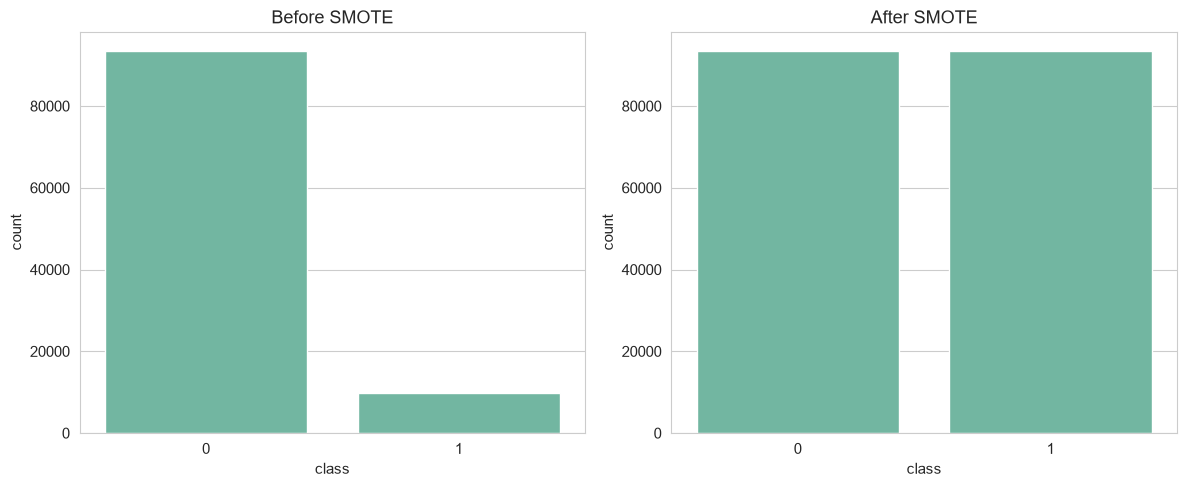

In [62]:
# =========================================================
# Before vs After SMOTE
# =========================================================

fig, ax = plt.subplots(

    1,

    2,

    figsize=(12,5)

)

sns.countplot(

    x=y_train,

    ax=ax[0]

)

ax[0].set_title(

    "Before SMOTE"

)

sns.countplot(

    x=y_train_resampled,

    ax=ax[1]

)

ax[1].set_title(

    "After SMOTE"

)

plt.tight_layout()

plt.show()

In [63]:
# =========================================================
# Save Final Processed Data
# =========================================================

X_train_resampled.to_csv(

    "../data/processed/X_train.csv",

    index=False

)

X_test.to_csv(

    "../data/processed/X_test.csv",

    index=False

)

y_train_resampled.to_csv(

    "../data/processed/y_train.csv",

    index=False

)

y_test.to_csv(

    "../data/processed/y_test.csv",

    index=False

)

fraud_processed.to_csv(

    "../data/processed/fraud_processed.csv",

    index=False

)

credit_clean.to_csv(

    "../data/processed/creditcard_processed.csv",

    index=False

)

print("="*60)

print("All processed datasets saved successfully.")

print("="*60)

All processed datasets saved successfully.


In [64]:
import os

print("Processed Folder Contents:\n")

for file in sorted(os.listdir("../data/processed")):
    print(file)

Processed Folder Contents:

X_test.csv
X_train.csv
creditcard_clean.csv
creditcard_processed.csv
fraud_clean.csv
fraud_feature_engineered.csv
fraud_processed.csv
ip_country_clean.csv
y_test.csv
y_train.csv


In [65]:
print(fraud_processed.shape)

print(X_train.shape)

print(X_test.shape)

print(X_train_resampled.shape)

(129146, 203)
(103316, 202)
(25830, 202)
(187004, 202)
